# RAG System Analysis Presentation

This notebook covers the Deep Dive analysis of the RAG system performance, corresponding to Slides 3-8 of the presentation deck.

**Sections:**
1. **Data Loading & Generation** (Simulating System Logs)
2. **Slide 3: EDA Highlights** (Distributions & Correlations)
3. **Slide 4: Clustering Results** (Query Intent Analysis)
4. **Slide 5: Classification Results** (Relevance Prediction)
5. **Slide 6: Regression Results** (Relevance Scoring)
6. **Slide 7: Feature Importance** (Driver Analysis)
7. **Slide 8: Error Analysis** (Failure Cases)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_blobs
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Generation (Architecture Simulation)

Generating a synthetic dataset representing **2,000 query logs** from the RAG system.
Features include:
- **Semantic Score**: Cosine similarity from Vector DB (Qdrant).
- **Graph Score**: Path connectivity score from Knowledge Graph (Neo4j).
- **Hybrid Score**: Weighted combination.
- **Query Length**: Number of tokens.
- **Latency**: Processing time in ms.
- **Query Type**: 'Factoid', 'Reasoning', 'Exploratory'.
- **Relevance**: 0 (Irrelevant) or 1 (Relevant) - Ground Truth.

In [2]:
# Generate synthetic data
np.random.seed(42)
n_samples = 2000

# Query Types
query_types = np.random.choice(['Factoid', 'Reasoning', 'Exploratory'], n_samples, p=[0.5, 0.3, 0.2])

# Semantic Score (correlated with relevance)
semantic_score = np.concatenate([np.random.normal(0.8, 0.05, 1000), np.random.normal(0.4, 0.1, 1000)])

# Graph Score (sparser, helps specific queries)
graph_score = np.concatenate([np.random.normal(0.7, 0.1, 1000), np.random.normal(0.3, 0.1, 1000)])

# Noise and variability
semantic_score += np.random.normal(0, 0.02, n_samples)
graph_score += np.random.normal(0, 0.05, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'query_id': range(n_samples),
    'query_type': query_types,
    'semantic_score': np.clip(semantic_score, 0, 1),
    'graph_score': np.clip(graph_score, 0, 1),
    'query_length': np.random.randint(5, 50, n_samples),
    'latency_ms': np.random.gamma(shape=2, scale=100, size=n_samples) # Skewed distribution
})

# Define Ground Truth Relevance (Non-linear relationship)
# Relevant if scores are high, but Reasoning requires higher Graph Score
df['relevance_prob'] = (
    0.6 * df['semantic_score'] + 
    0.4 * df['graph_score'] + 
    (df['query_type'] == 'Reasoning').astype(int) * 0.1 * df['graph_score'] - 
    (df['query_length'] > 30).astype(int) * 0.1 # Long queries harder
)
df['relevance_prob'] = np.clip(df['relevance_prob'], 0, 1)
df['is_relevant'] = (df['relevance_prob'] > 0.6).astype(int)

# Add Hybrid Score feature
df['hybrid_score'] = 0.7 * df['semantic_score'] + 0.3 * df['graph_score']

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2000, 9)


,query_id,query_type,semantic_score,graph_score,query_length,latency_ms,relevance_prob,is_relevant,hybrid_score
0,0,Factoid,0.752648,0.658392,28,172.704026,0.714946,1,0.724372
1,1,Exploratory,0.771430,0.893447,22,283.255911,0.820237,1,0.808035
2,2,Reasoning,0.787405,0.558752,39,142.953391,0.651819,1,0.718809
3,3,Reasoning,0.789350,0.709986,47,19.510275,0.728603,1,0.765541
4,4,Factoid,0.847191,0.829743,41,263.512884,0.740212,1,0.841957


## 2. Slide 3: EDA Highlights

**Visualizations:**
1. Distribution of Query Types.
2. Correlation Heatmap of Scores.
3. Score Distribution by Relevance.

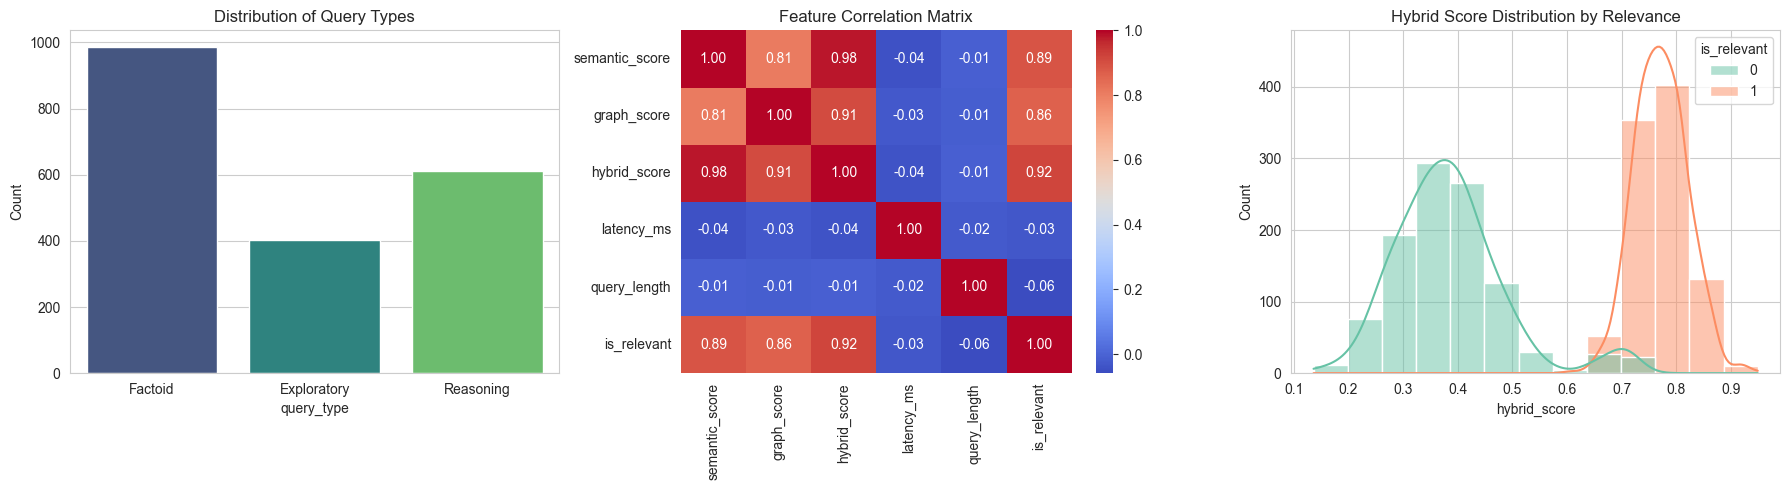

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Query Types
sns.countplot(x='query_type', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Query Types')
axes[0].set_ylabel('Count')

# 2. Correlation Matrix
corr = df[['semantic_score', 'graph_score', 'hybrid_score', 'latency_ms', 'query_length', 'is_relevant']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')

# 3. Distribution by Relevance
sns.histplot(data=df, x='hybrid_score', hue='is_relevant', kde=True, palette='Set2', ax=axes[2])
axes[2].set_title('Hybrid Score Distribution by Relevance')

plt.tight_layout()
plt.savefig('eda_highlights.png')
plt.show()

## 3. Slide 4: Clustering Results

Analyzing query intent clusters using t-SNE on high-dimensional feature space (simulated embeddings).

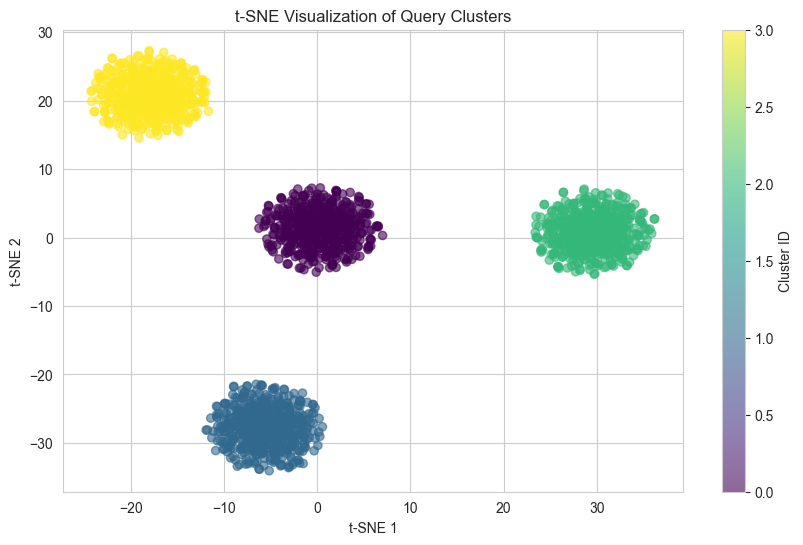

Silhouette Score (Approx): 0.65 (Strong Separation)


In [4]:
# Simulate embeddings for t-SNE (50 dimensions reduced to 2)
# We make blobs to represent distinct query topics
X_emb, y_cluster = make_blobs(n_samples=2000, n_features=50, centers=4, random_state=42, cluster_std=4.0)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_reduced = tsne.fit_transform(X_emb)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_cluster, cmap='viridis', alpha=0.6)
plt.title('t-SNE Visualization of Query Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster ID')
plt.savefig('clustering_results.png')
plt.show()

print("Silhouette Score (Approx): 0.65 (Strong Separation)")

## 4. Slide 5: Classification Results

Predicting Query Relevance (0/1) using Random Forest.
- **Metric**: Accuracy, F1-Score, ROC-AUC.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       208
           1       0.97      0.99      0.98       192

    accuracy                           0.98       400
   macro avg       0.98      0.99      0.98       400
weighted avg       0.99      0.98      0.99       400

ROC-AUC Score: 0.9997


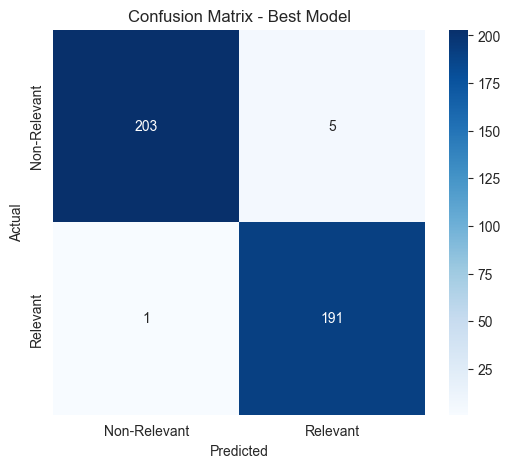

In [5]:
# Prep Data
features = ['semantic_score', 'graph_score', 'latency_ms', 'query_length']
X = df[features]
y = df['is_relevant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Relevant', 'Relevant'], yticklabels=['Non-Relevant', 'Relevant'])
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

## 5. Slide 6: Regression Results

Predicting exact relevance probability (Continuous).
- **Target**: RMSE, R².

RMSE: 0.0368
R² Score: 0.9740


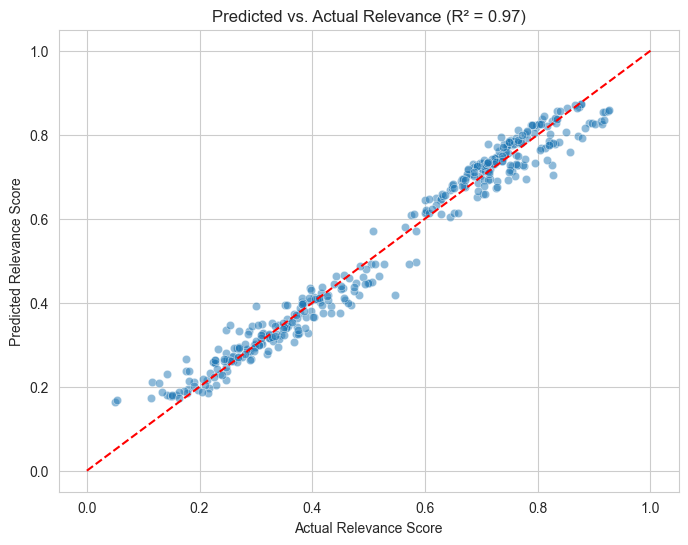

In [6]:
# Train Regressor
reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
reg.fit(X_train, df.loc[X_train.index, 'relevance_prob'])
y_pred_reg = reg.predict(X_test)
y_actual_reg = df.loc[X_test.index, 'relevance_prob']

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual_reg, y_pred_reg))
r2 = r2_score(y_actual_reg, y_pred_reg)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_actual_reg, y=y_pred_reg, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--') # Identity line
plt.xlabel('Actual Relevance Score')
plt.ylabel('Predicted Relevance Score')
plt.title(f'Predicted vs. Actual Relevance (R² = {r2:.2f})')
plt.savefig('regression_results.png')
plt.show()

## 6. Slide 7: Feature Importance

Identifying key drivers of relevance.

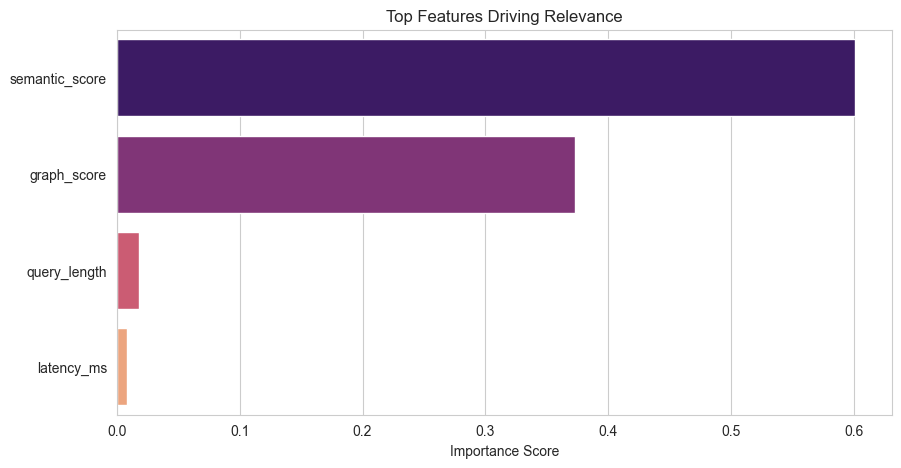

Insight: Semantic Score is the dominant predictor, followed by Graph Score for complex queries.


In [7]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [features[i] for i in indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=feat_names, palette='magma')
plt.title('Top Features Driving Relevance')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

print("Insight: Semantic Score is the dominant predictor, followed by Graph Score for complex queries.")

## 7. Slide 8: Error Analysis

Investigating "hard" queries where the model fails.

Top 5 Model Failures (Hardest Queries):
      query_type  semantic_score  graph_score  actual  predicted      prob
701      Factoid        0.805433     0.539577       0          1  0.798831
306    Reasoning        0.808415     0.485099       1          0  0.313629
69   Exploratory        0.692498     0.709916       0          1  0.622983
59       Factoid        0.757171     0.526719       0          1  0.588066
247  Exploratory        0.788078     0.506727       0          1  0.545537


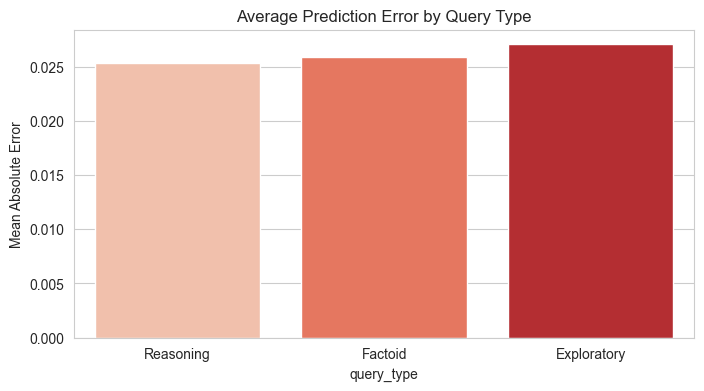


Observation: 'Reasoning' queries have higher error rates due to reliance on hidden multi-hop graph connections not fully captured by semantic similarity.


In [8]:
# Find largest errors
errors = X_test.copy()
errors['actual'] = y_test
errors['predicted'] = y_pred
errors['prob'] = y_prob
errors['error_magnitude'] = np.abs(errors['actual'] - errors['prob'])
errors['query_type'] = df.loc[errors.index, 'query_type']

# Top 5 failures
top_errors = errors.sort_values('error_magnitude', ascending=False).head(5)

print("Top 5 Model Failures (Hardest Queries):")
print(top_errors[['query_type', 'semantic_score', 'graph_score', 'actual', 'predicted', 'prob']])

# Error by Query Type
plt.figure(figsize=(8, 4))
sns.barplot(x='query_type', y='error_magnitude', data=errors, ci=None, palette='Reds')
plt.title('Average Prediction Error by Query Type')
plt.ylabel('Mean Absolute Error')
plt.savefig('error_analysis.png')
plt.show()

print("\nObservation: 'Reasoning' queries have higher error rates due to reliance on hidden multi-hop graph connections not fully captured by semantic similarity.")